# how to run the multiseed results:
0. run the notebook to process the new data (`00a_prepare_data_for_mmidas`) just hte first part for snRNAseq is fine. 
1. train augmenter   `sbatch scripts/train_aug_mixvae.sh`
2. then change the `augmenter_Dbh = "RNA_augmenter_Retroseq_updated_XXXX.pth"` in pyproject.yml (XXX is your date) 
3. 


# laod the multiseed results 

In [1]:
%load_ext autoreload
%autoreload 2

import sys, glob
import torch
print(sys.executable) 
print(torch.cuda.is_available())

/allen/aind/scratch/shuonan.chen/miniconda3/envs/mmidas/bin/python
True


In [2]:
torch.cuda.set_device(0)
torch.cuda.get_device_name(torch.cuda.current_device())

free_gpus = []
for i in range(torch.cuda.device_count()):
    if torch.cuda.get_device_properties(i).total_memory - torch.cuda.memory_allocated(i) > 0:
        free_gpus.append(i)
device = torch.device(f"cuda:{free_gpus[0]}")
device

device(type='cuda', index=0)

In [3]:
torch.cuda.get_device_name(torch.cuda.current_device())

'NVIDIA A100-PCIE-40GB'

In [4]:
import scanpy as sc
import anndata as ad
import umap
import numpy as np
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

from mmidas.vaegan import vae_gan
from mmidas.utils.config_tools import get_paths
from mmidas.utils.data_tools import load_data_BN, load_data_raw,  get_loaders, generate_colors
from mmidas.utils.augmentation import get_loader

from mmidas.cplMixVAE import cpl_mixVAE
from mmidas.eval import summarize_inference
from mmidas.utils.cluster_analysis import K_selection
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns


/home/shuonan.chen/.local/lib/python3.9/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/home/shuonan.chen/.local/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
toml_file = 'pyproject.toml'
device = 0
config = get_paths(toml_file=toml_file)
aug_path = config['paths']['main_dir'] / config['paths']['models']
aug_path

/allen/aind/scratch/shuonan.chen/code/LC-NE-MixRep/pyproject.toml
Getting files directories belong to data...
Getting files directories belong to models...


PosixPath('/allen/aind/scratch/shuonan.chen/code/LC-NE-MixRep/models')

# load data

In [14]:
data = load_data_BN()
data_loader = get_loader(x=data['log1p'] , batch_size=256, training=False)

defined CPM scalar is 1000000.0
Number of cells: 4845, Number of genes: 1502
Dataloader for augmentation created!


In [15]:
data['log1p'].max(), data['log1p'].min(), data['log1p'].mean()

(10.925062, 7.174809e-06, 4.565406)

# load the results

In [16]:

results_path = config['paths']['main_dir'] / config['paths']['saving_path_randomseed']
results_path


PosixPath('/allen/aind/scratch/shuonan.chen/code/LC-NE-MixRep/results/randomseedresults/4845data')

In [17]:
myinterestedseed = [1,2,3,4,5] # test 1
# myinterestedseed = [111,222,333,444,555]  # test 2
available_models_all = glob.glob(str(results_path) + '/randomseed*')
available_models = [s for s in available_models_all if any(f"randomseed_{i}_" in s for i in myinterestedseed)]
len(available_models)

5

In [18]:
myinterestedseed

[1, 2, 3, 4, 5]

In [19]:
def get_model_params(selected_model_file):
    param_vairables = selected_model_file.split('/')[-1].split('_')
    params = {}
    for p in range(0, len(param_vairables), 2):
        try:
            params[param_vairables[p]] = float(param_vairables[p+1])
            if params[param_vairables[p]] == int(params[param_vairables[p]]):
                params[param_vairables[p]] = int(params[param_vairables[p]])
        except ValueError:
            params[param_vairables[p]] = param_vairables[p+1]
    return(params)

def print_dates_model_info(trained_models_ALLDATE,all_time_stamps_available):
    '''
    check all the models, their dates and how many are available 
    '''
    from pprint import pprint 
    for m in all_time_stamps_available:
        print(m, len([modelname for modelname in trained_models_ALLDATE if m in modelname]))
        pprint([modelname.split('/')[-1].split('cpl_mixVAE_model_after_pruning_')[-1] for modelname in trained_models_ALLDATE if m in modelname])
        
def get_trained_models(trained_models_ALLDATE, all_time_stamps_available):
    '''this will take the first date if there are multple with the same length!'''
    counts = {m: sum(m in modelname for modelname in trained_models_ALLDATE)
              for m in all_time_stamps_available}
    max_count = max(counts.values())
    best_m_list = [m for m, c in counts.items() if c == max_count]
#     print(best_m_list)
    best_m = best_m_list[-1] 
    print('***** using model from this date:',best_m)
    trained_models = ([models for models in trained_models_ALLDATE if best_m in models])
    return(trained_models)


*** random seed 0 
***** using model from this date: 2026-02-26-03-47-59
Initializing mixvae model ...
0
--->NVIDIA A100-PCIE-40GB
Model /cpl_mixVAE_model_after_pruning_10_2026-02-26-03-47-59.pth
Model /cpl_mixVAE_model_after_pruning_11_2026-02-26-03-47-59.pth
Model /cpl_mixVAE_model_after_pruning_12_2026-02-26-03-47-59.pth
Model /cpl_mixVAE_model_after_pruning_13_2026-02-26-03-47-59.pth
Model /cpl_mixVAE_model_after_pruning_14_2026-02-26-03-47-59.pth
Model /cpl_mixVAE_model_after_pruning_1_2026-02-26-03-47-59.pth
Model /cpl_mixVAE_model_after_pruning_2_2026-02-26-03-47-59.pth
Model /cpl_mixVAE_model_after_pruning_3_2026-02-26-03-47-59.pth
Model /cpl_mixVAE_model_after_pruning_4_2026-02-26-03-47-59.pth
Model /cpl_mixVAE_model_after_pruning_5_2026-02-26-03-47-59.pth
Model /cpl_mixVAE_model_after_pruning_6_2026-02-26-03-47-59.pth
Model /cpl_mixVAE_model_after_pruning_7_2026-02-26-03-47-59.pth
Model /cpl_mixVAE_model_after_pruning_8_2026-02-26-03-47-59.pth
Model /cpl_mixVAE_model_after_p

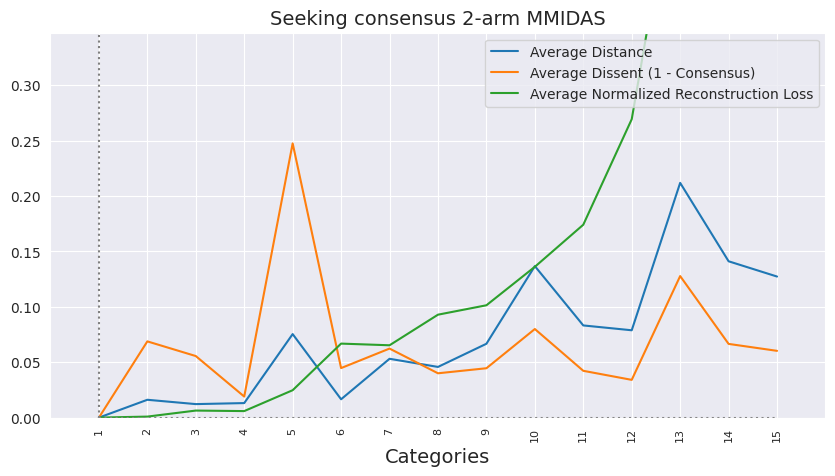

Selected number of clusters: 1 with consensus 1.0
Seed 0: Selected K = 1

*** random seed 1 
***** using model from this date: 2026-02-26-04-41-13
Initializing mixvae model ...
0
--->NVIDIA A100-PCIE-40GB
Model /cpl_mixVAE_model_after_pruning_10_2026-02-26-04-41-13.pth
Model /cpl_mixVAE_model_after_pruning_11_2026-02-26-04-41-13.pth
Model /cpl_mixVAE_model_after_pruning_12_2026-02-26-04-41-13.pth
Model /cpl_mixVAE_model_after_pruning_13_2026-02-26-04-41-13.pth
Model /cpl_mixVAE_model_after_pruning_14_2026-02-26-04-41-13.pth
Model /cpl_mixVAE_model_after_pruning_1_2026-02-26-04-41-13.pth
Model /cpl_mixVAE_model_after_pruning_2_2026-02-26-04-41-13.pth
Model /cpl_mixVAE_model_after_pruning_3_2026-02-26-04-41-13.pth
Model /cpl_mixVAE_model_after_pruning_4_2026-02-26-04-41-13.pth
Model /cpl_mixVAE_model_after_pruning_5_2026-02-26-04-41-13.pth
Model /cpl_mixVAE_model_after_pruning_6_2026-02-26-04-41-13.pth
Model /cpl_mixVAE_model_after_pruning_7_2026-02-26-04-41-13.pth
Model /cpl_mixVAE_mode

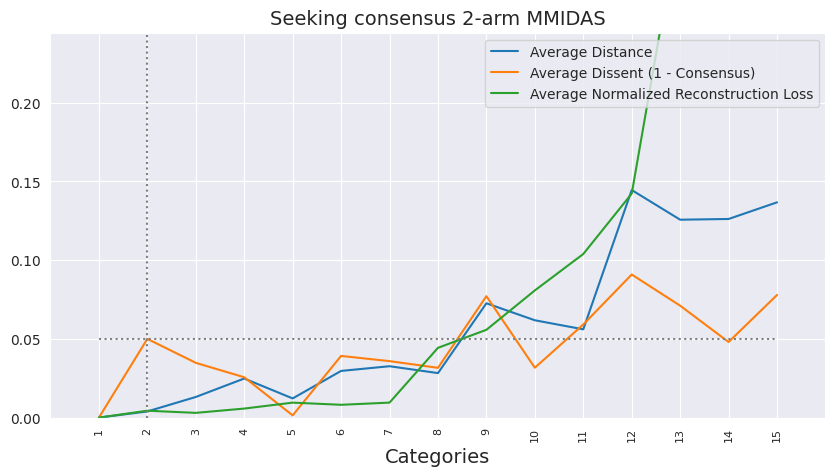

Selected number of clusters: 2 with consensus 0.95
Seed 1: Selected K = 2

*** random seed 2 
***** using model from this date: 2026-02-26-06-29-20
Initializing mixvae model ...
0
--->NVIDIA A100-PCIE-40GB
Model /cpl_mixVAE_model_after_pruning_10_2026-02-26-06-29-20.pth
Model /cpl_mixVAE_model_after_pruning_11_2026-02-26-06-29-20.pth
Model /cpl_mixVAE_model_after_pruning_12_2026-02-26-06-29-20.pth
Model /cpl_mixVAE_model_after_pruning_13_2026-02-26-06-29-20.pth
Model /cpl_mixVAE_model_after_pruning_14_2026-02-26-06-29-20.pth
Model /cpl_mixVAE_model_after_pruning_1_2026-02-26-06-29-20.pth
Model /cpl_mixVAE_model_after_pruning_2_2026-02-26-06-29-20.pth
Model /cpl_mixVAE_model_after_pruning_3_2026-02-26-06-29-20.pth
Model /cpl_mixVAE_model_after_pruning_4_2026-02-26-06-29-20.pth
Model /cpl_mixVAE_model_after_pruning_5_2026-02-26-06-29-20.pth
Model /cpl_mixVAE_model_after_pruning_6_2026-02-26-06-29-20.pth
Model /cpl_mixVAE_model_after_pruning_7_2026-02-26-06-29-20.pth
Model /cpl_mixVAE_mod

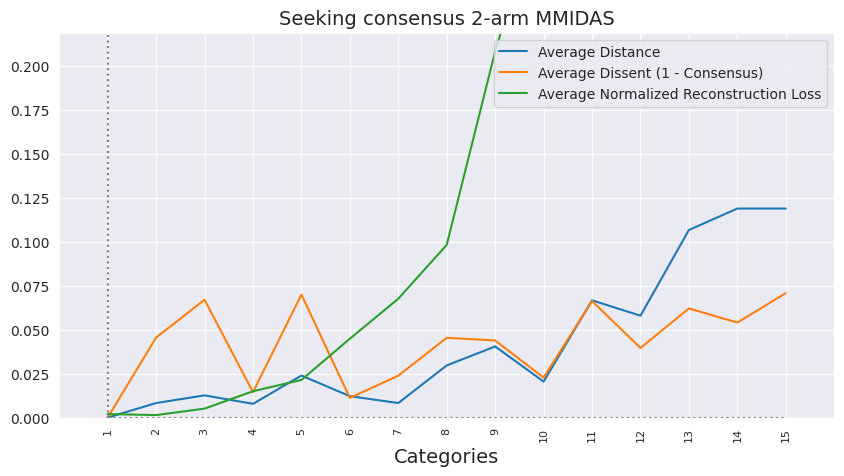

Selected number of clusters: 1 with consensus 1.0
Seed 2: Selected K = 1

*** random seed 3 
***** using model from this date: 2026-02-26-06-47-09
Initializing mixvae model ...
0
--->NVIDIA A100-PCIE-40GB
Model /cpl_mixVAE_model_after_pruning_10_2026-02-26-06-47-09.pth
Model /cpl_mixVAE_model_after_pruning_11_2026-02-26-06-47-09.pth
Model /cpl_mixVAE_model_after_pruning_12_2026-02-26-06-47-09.pth
Model /cpl_mixVAE_model_after_pruning_13_2026-02-26-06-47-09.pth
Model /cpl_mixVAE_model_after_pruning_14_2026-02-26-06-47-09.pth
Model /cpl_mixVAE_model_after_pruning_1_2026-02-26-06-47-09.pth
Model /cpl_mixVAE_model_after_pruning_2_2026-02-26-06-47-09.pth
Model /cpl_mixVAE_model_after_pruning_3_2026-02-26-06-47-09.pth
Model /cpl_mixVAE_model_after_pruning_4_2026-02-26-06-47-09.pth
Model /cpl_mixVAE_model_after_pruning_5_2026-02-26-06-47-09.pth
Model /cpl_mixVAE_model_after_pruning_6_2026-02-26-06-47-09.pth
Model /cpl_mixVAE_model_after_pruning_7_2026-02-26-06-47-09.pth
Model /cpl_mixVAE_mode

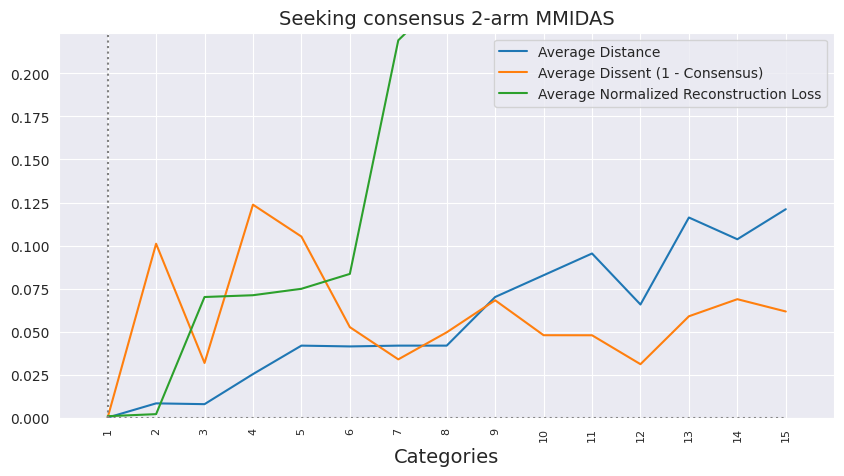

Selected number of clusters: 1 with consensus 1.0
Seed 3: Selected K = 1

*** random seed 4 
***** using model from this date: 2026-02-26-17-15-09
Initializing mixvae model ...
0
--->NVIDIA A100-PCIE-40GB
Model /cpl_mixVAE_model_after_pruning_10_2026-02-26-17-15-09.pth
Model /cpl_mixVAE_model_after_pruning_11_2026-02-26-17-15-09.pth
Model /cpl_mixVAE_model_after_pruning_12_2026-02-26-17-15-09.pth
Model /cpl_mixVAE_model_after_pruning_13_2026-02-26-17-15-09.pth
Model /cpl_mixVAE_model_after_pruning_14_2026-02-26-17-15-09.pth
Model /cpl_mixVAE_model_after_pruning_1_2026-02-26-17-15-09.pth
Model /cpl_mixVAE_model_after_pruning_2_2026-02-26-17-15-09.pth
Model /cpl_mixVAE_model_after_pruning_3_2026-02-26-17-15-09.pth
Model /cpl_mixVAE_model_after_pruning_4_2026-02-26-17-15-09.pth
Model /cpl_mixVAE_model_after_pruning_5_2026-02-26-17-15-09.pth
Model /cpl_mixVAE_model_after_pruning_6_2026-02-26-17-15-09.pth
Model /cpl_mixVAE_model_after_pruning_7_2026-02-26-17-15-09.pth
Model /cpl_mixVAE_mode

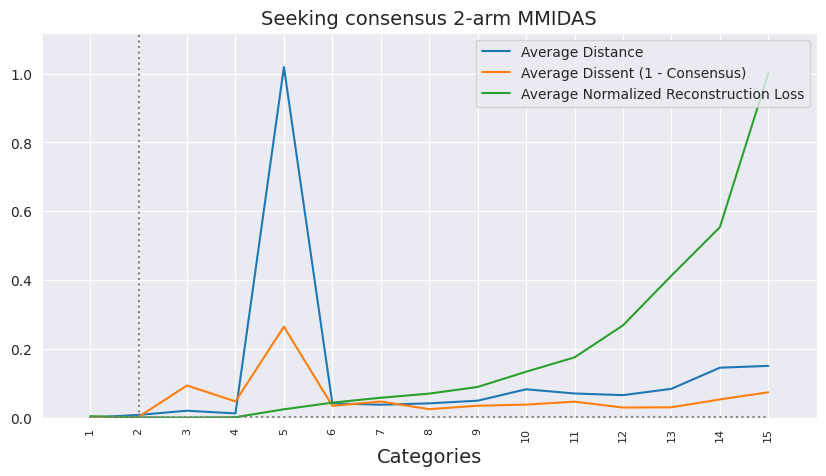

Selected number of clusters: 2 with consensus 0.9978813559322034
Seed 4: Selected K = 2


In [20]:
all_results = []
all_K_values = []
for i in range(len(myinterestedseed)):
    print(f"\n*** random seed {i} ")
    selected_model_file = available_models[i]
    trained_models_ALLDATE = glob.glob(selected_model_file + '/model/cpl_mixVAE_model_*')  
    slitter = 'cpl_mixVAE_model_before_pruning_'
    all_time_stamps_available = [m.split('/')[-1].split(slitter)[-1].split('.pth')[0] for m in trained_models_ALLDATE if slitter in m]
    trained_models = get_trained_models(trained_models_ALLDATE, all_time_stamps_available)
    params = get_model_params(selected_model_file)
    
    print('Initializing mixvae model ...')
    mixvae = cpl_mixVAE(saving_folder=selected_model_file, device=device)
    mixvae.init_model(
                    n_categories=params['Cdim'],
                    state_dim=params['Sdim'],
                    input_dim=data['log1p'].shape[1],
                    fc_dim=params['fcdim'],
                    lowD_dim=params['Zdim'],
                    n_arm=params['narm'],
                    tau=params['tau'],
                    )
    alldata_loader,train_loader,test_loader, _, _, _ = get_loaders(x=data['log1p'],batch_size=params['nbatch'], 
                                                                   seed=params['randomseed'])
    mixvae.variational = False
    summary_dict = summarize_inference(mixvae, trained_models, test_loader)
    num_pruned, l_recon_mean, consensus, K = K_selection(summary_dict, mixvae.n_categories, mixvae.n_arm, 
                                                         thr=0.99, plot_reconst=True)    
    all_results.append({
        'num_pruned': num_pruned,
        'l_recon_mean': l_recon_mean,
        'consensus': consensus,
        'summary_dict': summary_dict
    })
    all_K_values.append(K)
    print(f"Seed {i}: Selected K = {K}")



In [21]:
for m,n in test_loader:
    print(m.shape, n.shape)

torch.Size([256, 1502]) torch.Size([256])
torch.Size([229, 1502]) torch.Size([229])


In [22]:
# Now compute the mean across all seeds
print(f"\nComputing mean across {len(myinterestedseed)} seeds...")
common_num_pruned = all_results[0]['num_pruned']
all_l_recon = []
all_consensus = []
all_d_qc = []

for result in all_results:
    assert np.array_equal(result['num_pruned'], common_num_pruned), "num_pruned should be the same across seeds"    
    all_l_recon.append(result['l_recon_mean'])
    all_consensus.append(result['consensus'])
    indx = np.argsort(result['summary_dict']['num_pruned'])
    all_d_qc.append(np.array(result['summary_dict']['d_qc'])[indx])

# Compute means and standard deviations
mean_l_recon = np.mean(all_l_recon, axis=0)
std_l_recon = np.std(all_l_recon, axis=0)

mean_consensus = np.mean(all_consensus, axis=0)
std_consensus = np.std(all_consensus, axis=0)

mean_d_qc = np.mean(all_d_qc, axis=0)
std_d_qc = np.std(all_d_qc, axis=0)

mean_dissent = 1 - mean_consensus
std_dissent = std_consensus  # std of (1-x) = std of x

# Normalize reconstruction loss for plotting
norm_l_recon = mean_l_recon/ data['log1p'].shape[1]
norm_std_l_recon = std_l_recon / data['log1p'].shape[1]



Computing mean across 5 seeds...


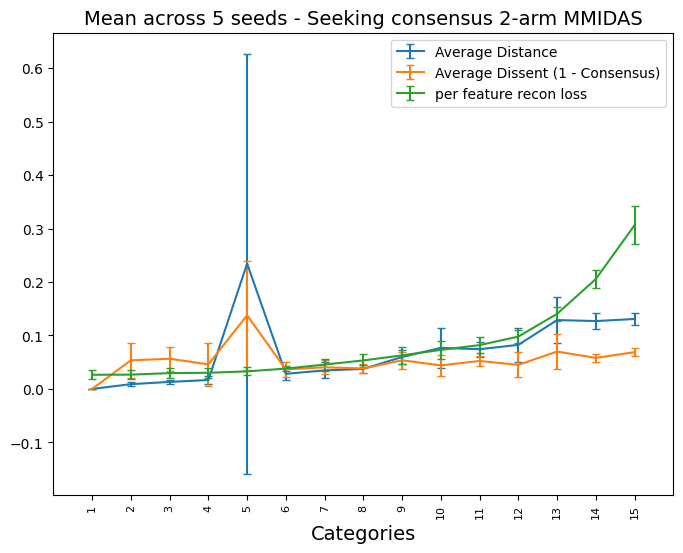

Selected K values across seeds: [1, 2, 1, 1, 2]


In [24]:


# Plot the averaged results
fig = plt.figure(figsize=[8, 6])
ax = fig.add_subplot()
ax.errorbar(common_num_pruned, mean_d_qc, yerr=std_d_qc, label='Average Distance', capsize=3)
ax.errorbar(common_num_pruned, mean_dissent, yerr=std_dissent, label='Average Dissent (1 - Consensus)', capsize=3)
ax.errorbar(common_num_pruned, norm_l_recon,yerr=norm_std_l_recon,
           label='per feature recon loss', capsize=3)

ax.set_xlim([np.min(common_num_pruned)-1, mixvae.n_categories + 1])
ax.set_xlabel('Categories', fontsize=14)
ax.set_xticks(common_num_pruned)
ax.set_xticklabels(common_num_pruned, fontsize=8, rotation=90)
ax.set_title(f'Mean across {len(myinterestedseed)} seeds - Seeking consensus {mixvae.n_arm}-arm MMIDAS', fontsize=14)

ax.legend(loc='upper right')
plt.show()

print(f"Selected K values across seeds: {all_K_values}")

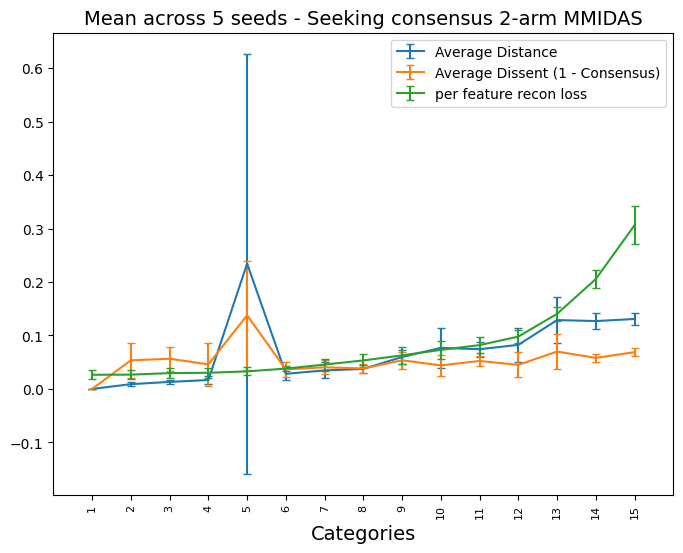

Selected K values across seeds: [1, 2, 1, 1, 2]


In [25]:


# Plot the averaged results
fig = plt.figure(figsize=[8, 6])
ax = fig.add_subplot()
ax.errorbar(common_num_pruned, mean_d_qc, yerr=std_d_qc, label='Average Distance', capsize=3)
ax.errorbar(common_num_pruned, mean_dissent, yerr=std_dissent, label='Average Dissent (1 - Consensus)', capsize=3)
ax.errorbar(common_num_pruned, norm_l_recon,yerr=norm_std_l_recon,
           label='per feature recon loss', capsize=3)

ax.set_xlim([np.min(common_num_pruned)-1, mixvae.n_categories + 1])
ax.set_xlabel('Categories', fontsize=14)
ax.set_xticks(common_num_pruned)
ax.set_xticklabels(common_num_pruned, fontsize=8, rotation=90)
ax.set_title(f'Mean across {len(myinterestedseed)} seeds - Seeking consensus {mixvae.n_arm}-arm MMIDAS', fontsize=14)

ax.legend(loc='upper right')
plt.show()

print(f"Selected K values across seeds: {all_K_values}")

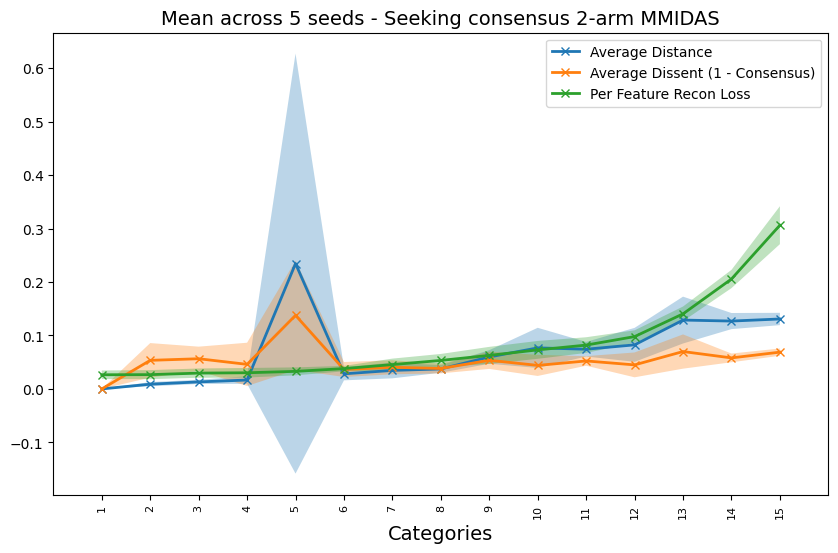

Selected K values across seeds: [1, 2, 1, 1, 2]


In [26]:
fig = plt.figure(figsize=[10, 6])
ax = fig.add_subplot()

# Plot lines with shaded bands instead of error bars
ax.plot(common_num_pruned, mean_d_qc, label='Average Distance', marker='x',linewidth=2)
ax.fill_between(common_num_pruned, mean_d_qc - std_d_qc, mean_d_qc + std_d_qc, alpha=0.3)

ax.plot(common_num_pruned, mean_dissent, label='Average Dissent (1 - Consensus)', marker='x',linewidth=2)
ax.fill_between(common_num_pruned, mean_dissent - std_dissent, mean_dissent + std_dissent, alpha=0.3)

ax.plot(common_num_pruned, norm_l_recon, label='Per Feature Recon Loss', marker='x',linewidth=2)
ax.fill_between(common_num_pruned, norm_l_recon - norm_std_l_recon, norm_l_recon + norm_std_l_recon, alpha=0.3)

ax.set_xlim([np.min(common_num_pruned)-1, mixvae.n_categories + 1])
ax.set_xlabel('Categories', fontsize=14)
ax.set_xticks(common_num_pruned)
ax.set_xticklabels(common_num_pruned, fontsize=8, rotation=90)
ax.set_title(f'Mean across {len(myinterestedseed)} seeds - Seeking consensus {mixvae.n_arm}-arm MMIDAS', fontsize=14)

ax.legend(loc='upper right')
plt.show()

print(f"Selected K values across seeds: {all_K_values}")



# here i want to save the results for the sillouette score analysis elsewhere

In [27]:
myinterestedseed

[1, 2, 3, 4, 5]

In [28]:
all_results=[]

import pickle as pkl
for i in range(len(myinterestedseed)):
    print(f"\n*** random seed {i} ")
    selected_model_file = available_models[i] # random seed is purely used to select the models (trained with random seed)
    trained_models_ALLDATE = glob.glob(selected_model_file + '/model/cpl_mixVAE_model_*')  
    slitter = 'cpl_mixVAE_model_before_pruning_' # splitter
    all_time_stamps_available = [m.split('/')[-1].split(slitter)[-1].split('.pth')[0] for m in trained_models_ALLDATE if slitter in m]
    trained_models = get_trained_models(trained_models_ALLDATE, all_time_stamps_available)
    params = get_model_params(selected_model_file)
    mixvae = cpl_mixVAE(saving_folder=selected_model_file, device=device)
    mixvae.init_model(n_categories=params['Cdim'],state_dim=params['Sdim'],
                    input_dim=data['log1p'].shape[1],fc_dim=params['fcdim'],
                    lowD_dim=params['Zdim'],n_arm=params['narm'],tau=params['tau'],)
    alldata_loader,train_loader,test_loader, _, _, _ = get_loaders(x=data['log1p'],batch_size=params['nbatch'], 
                                                                   seed=params['randomseed'])
    mixvae.variational = False
    for file in trained_models: # 1-15
        file_name_ind = file.rfind('/')
        print(f'Model {file[file_name_ind:]}')
        all_results.append({"seed_i": i, "model_file": file, "outcome": summarize_inference(mixvae, file, alldata_loader)})

mmidas_res_path = "/home/shuonan.chen/scratch_shuonan/code/LCNE_transcriptomics/data/snRNA/all_mmidas_outcome_new_11seed_v2.pkl"
pkl.dump(all_results,file =open(mmidas_res_path, 'wb'))


*** random seed 0 
***** using model from this date: 2026-02-26-03-47-59
0
--->NVIDIA A100-PCIE-40GB
Model /cpl_mixVAE_model_after_pruning_10_2026-02-26-03-47-59.pth
Model /cpl_mixVAE_model_after_pruning_10_2026-02-26-03-47-59.pth
Model /cpl_mixVAE_model_after_pruning_11_2026-02-26-03-47-59.pth
Model /cpl_mixVAE_model_after_pruning_11_2026-02-26-03-47-59.pth
Model /cpl_mixVAE_model_after_pruning_12_2026-02-26-03-47-59.pth
Model /cpl_mixVAE_model_after_pruning_12_2026-02-26-03-47-59.pth
Model /cpl_mixVAE_model_after_pruning_13_2026-02-26-03-47-59.pth
Model /cpl_mixVAE_model_after_pruning_13_2026-02-26-03-47-59.pth
Model /cpl_mixVAE_model_after_pruning_14_2026-02-26-03-47-59.pth
Model /cpl_mixVAE_model_after_pruning_14_2026-02-26-03-47-59.pth
Model /cpl_mixVAE_model_after_pruning_1_2026-02-26-03-47-59.pth
Model /cpl_mixVAE_model_after_pruning_1_2026-02-26-03-47-59.pth
Model /cpl_mixVAE_model_after_pruning_2_2026-02-26-03-47-59.pth
Model /cpl_mixVAE_model_after_pruning_2_2026-02-26-03-47

Model /cpl_mixVAE_model_after_pruning_11_2026-02-26-17-15-09.pth
Model /cpl_mixVAE_model_after_pruning_11_2026-02-26-17-15-09.pth
Model /cpl_mixVAE_model_after_pruning_12_2026-02-26-17-15-09.pth
Model /cpl_mixVAE_model_after_pruning_12_2026-02-26-17-15-09.pth
Model /cpl_mixVAE_model_after_pruning_13_2026-02-26-17-15-09.pth
Model /cpl_mixVAE_model_after_pruning_13_2026-02-26-17-15-09.pth
Model /cpl_mixVAE_model_after_pruning_14_2026-02-26-17-15-09.pth
Model /cpl_mixVAE_model_after_pruning_14_2026-02-26-17-15-09.pth
Model /cpl_mixVAE_model_after_pruning_1_2026-02-26-17-15-09.pth
Model /cpl_mixVAE_model_after_pruning_1_2026-02-26-17-15-09.pth
Model /cpl_mixVAE_model_after_pruning_2_2026-02-26-17-15-09.pth
Model /cpl_mixVAE_model_after_pruning_2_2026-02-26-17-15-09.pth
Model /cpl_mixVAE_model_after_pruning_3_2026-02-26-17-15-09.pth
Model /cpl_mixVAE_model_after_pruning_3_2026-02-26-17-15-09.pth
Model /cpl_mixVAE_model_after_pruning_4_2026-02-26-17-15-09.pth
Model /cpl_mixVAE_model_after_pr

In [29]:
len(np.unique([poo['seed_i'] for poo in all_results])), len(np.unique([poo['outcome']['num_pruned'][0] for poo in all_results]))

(5, 15)